In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from scipy.cluster.hierarchy import (linkage, dendrogram, cut_tree)
import os
os.chdir('/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 7')
os.getcwd()

'/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 7'

In [2]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.stats.anova import anova_lm
from pathlib import Path

In [3]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                        summarize,
                        contrast)
from ISLP import confusion_table
#from ISLP.models import contrast
from ISLP.bart import BART
from ISLP.cluster import compute_linkage

In [4]:
from sklearn.discriminant_analysis import \
                        (LinearDiscriminantAnalysis as LDA,
                        QuadraticDiscriminantAnalysis as QDA)
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import \
                            (mean_squared_error as myMSE, 
                            accuracy_score, 
                            classification_report, 
                            confusion_matrix)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (GradientBoostingRegressor, 
                                BaggingClassifier,
                                RandomForestClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (KMeans, AgglomerativeClustering)

# Exploratory data analysis

In [5]:
df = pd.read_csv('WineCluster.csv')
df = pd.DataFrame(df)

In [6]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [7]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [9]:
df.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')

In [10]:
count = sum(not isinstance(item, (int, float)) for item in df)
print("Number of non-numeric values:", count)

Number of non-numeric values: 13


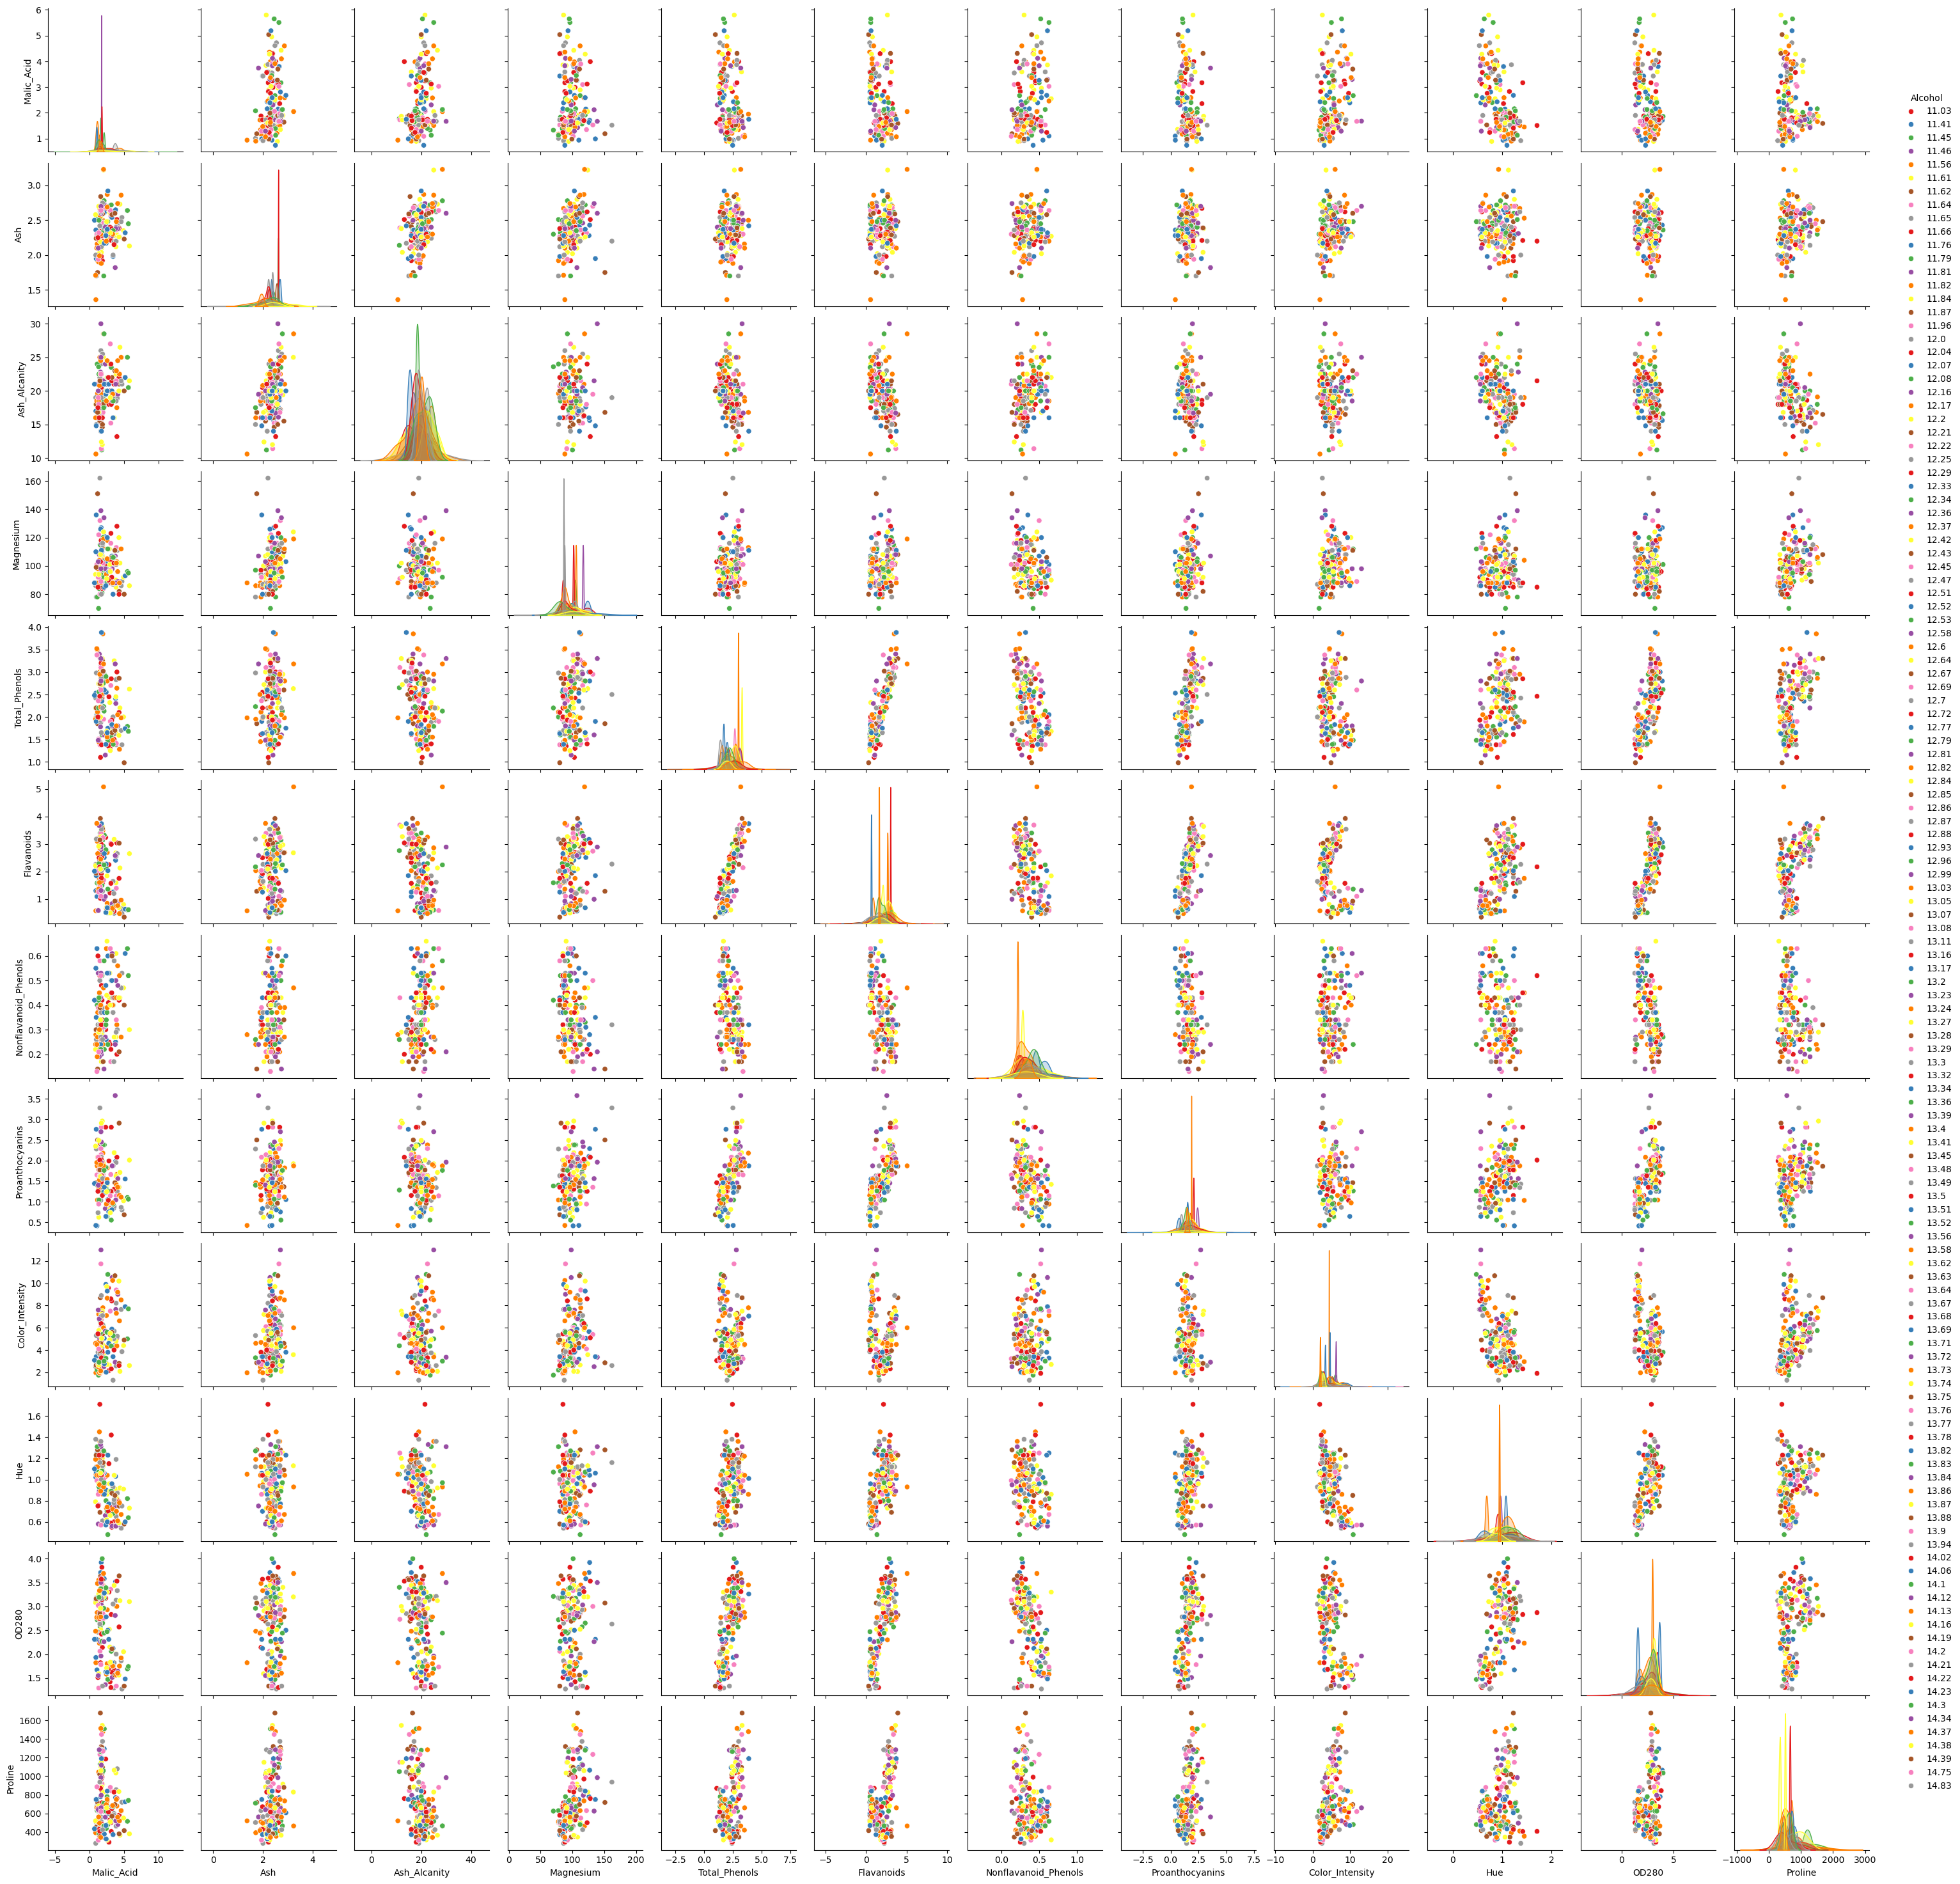

In [11]:
sns.pairplot(df, hue = 'Alcohol', palette = 'Set1')
plt.show()

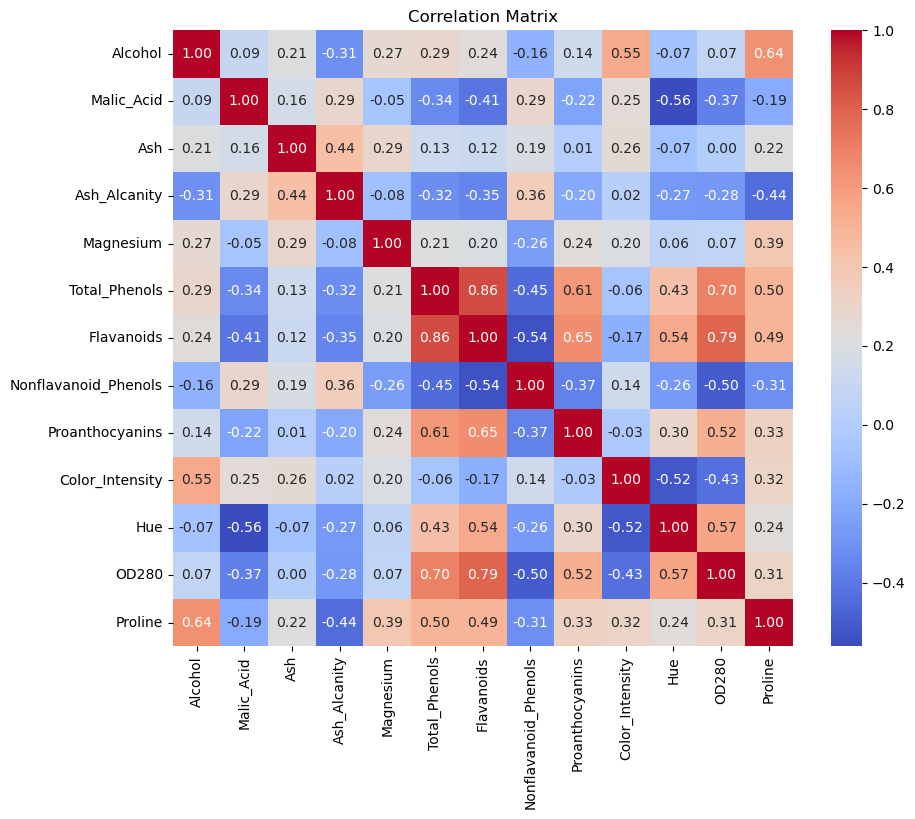

In [12]:
# Correlation matrix
numMatrix = df.select_dtypes(exclude = ['object'])
correlation_matrix = numMatrix.corr() # Compute correlations
plt.figure(figsize=(10, 8)) # Adjust figure size
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title('Correlation Matrix')
plt.show()

Alcohol and Proline by Color Intensity


<Figure size 1000x800 with 0 Axes>

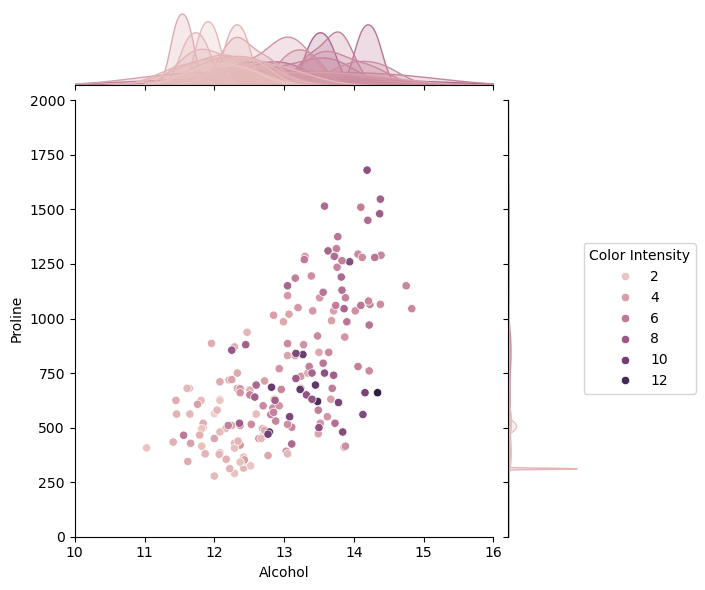

In [13]:
# Alcohol and Proline by Color Intensity
print('Alcohol and Proline by Color Intensity')
plt.figure(figsize = (10,8))
aPlot = sns.jointplot(xlim = (10, 16), ylim = (0,2000), x = 'Alcohol', y = 'Proline', hue = 'Color_Intensity', data = df)
aPlot.ax_joint.legend(
    loc='center right', 
    bbox_to_anchor=(1.5, 0.5), # Moves the legend outside the plot area
    title = 'Color Intensity',
    frameon  =True # Add a frame around the legend
    )
plt.xlabel("Alcohol")
plt.ylabel("Proline")
plt.show()

In [14]:
df.skew()

Alcohol                -0.051482
Malic_Acid              1.039651
Ash                    -0.176699
Ash_Alcanity            0.213047
Magnesium               1.098191
Total_Phenols           0.086639
Flavanoids              0.025344
Nonflavanoid_Phenols    0.450151
Proanthocyanins         0.517137
Color_Intensity         0.868585
Hue                     0.021091
OD280                  -0.307285
Proline                 0.767822
dtype: float64

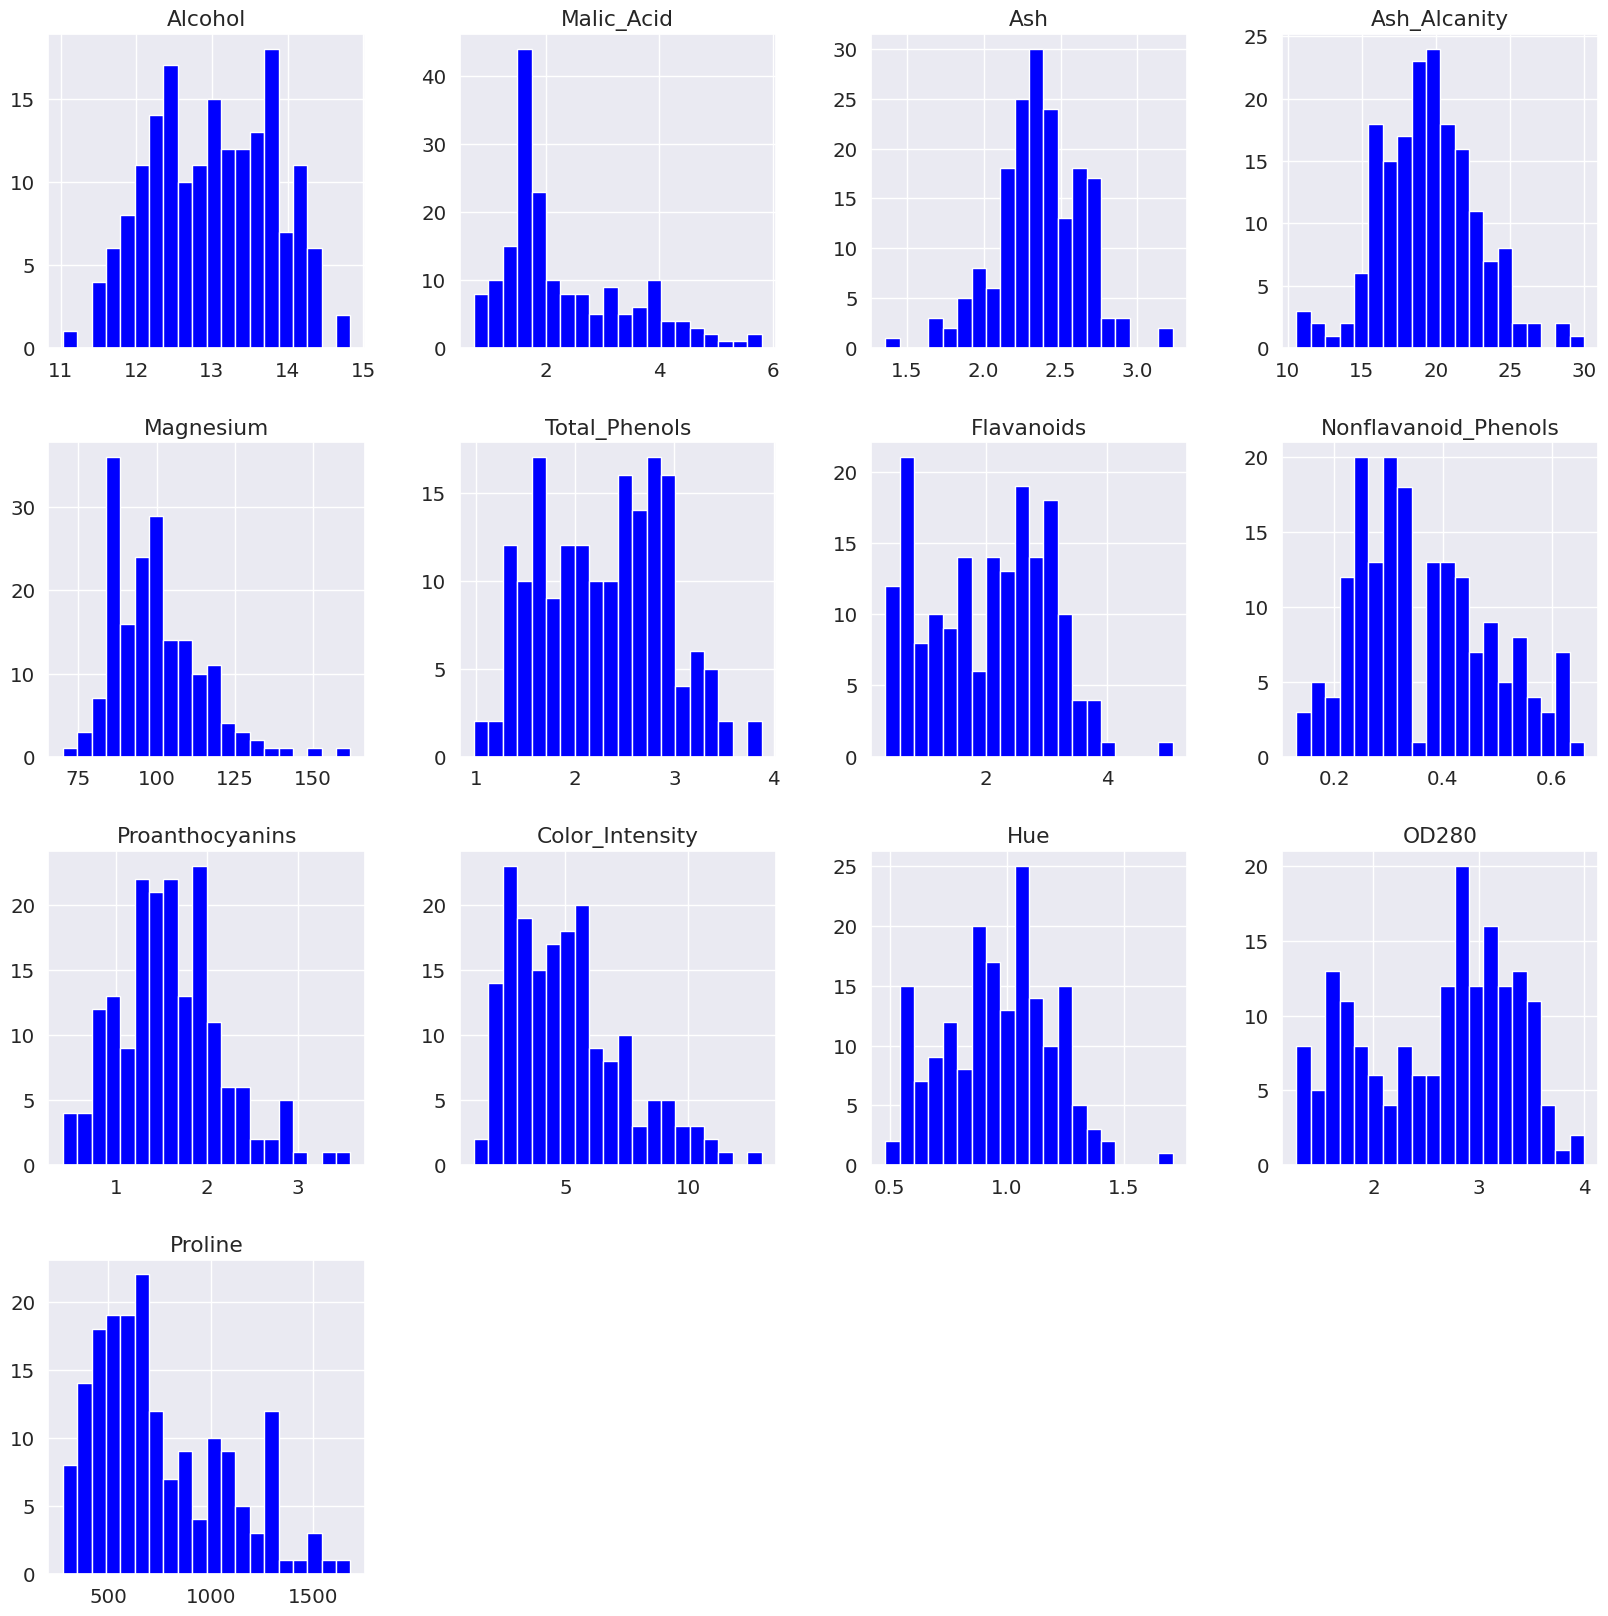

In [15]:
sns.set(style='darkgrid',font_scale=1.3, rc={'figure.figsize':(20,20)})
ax=df.hist(bins=20,color='blue' )

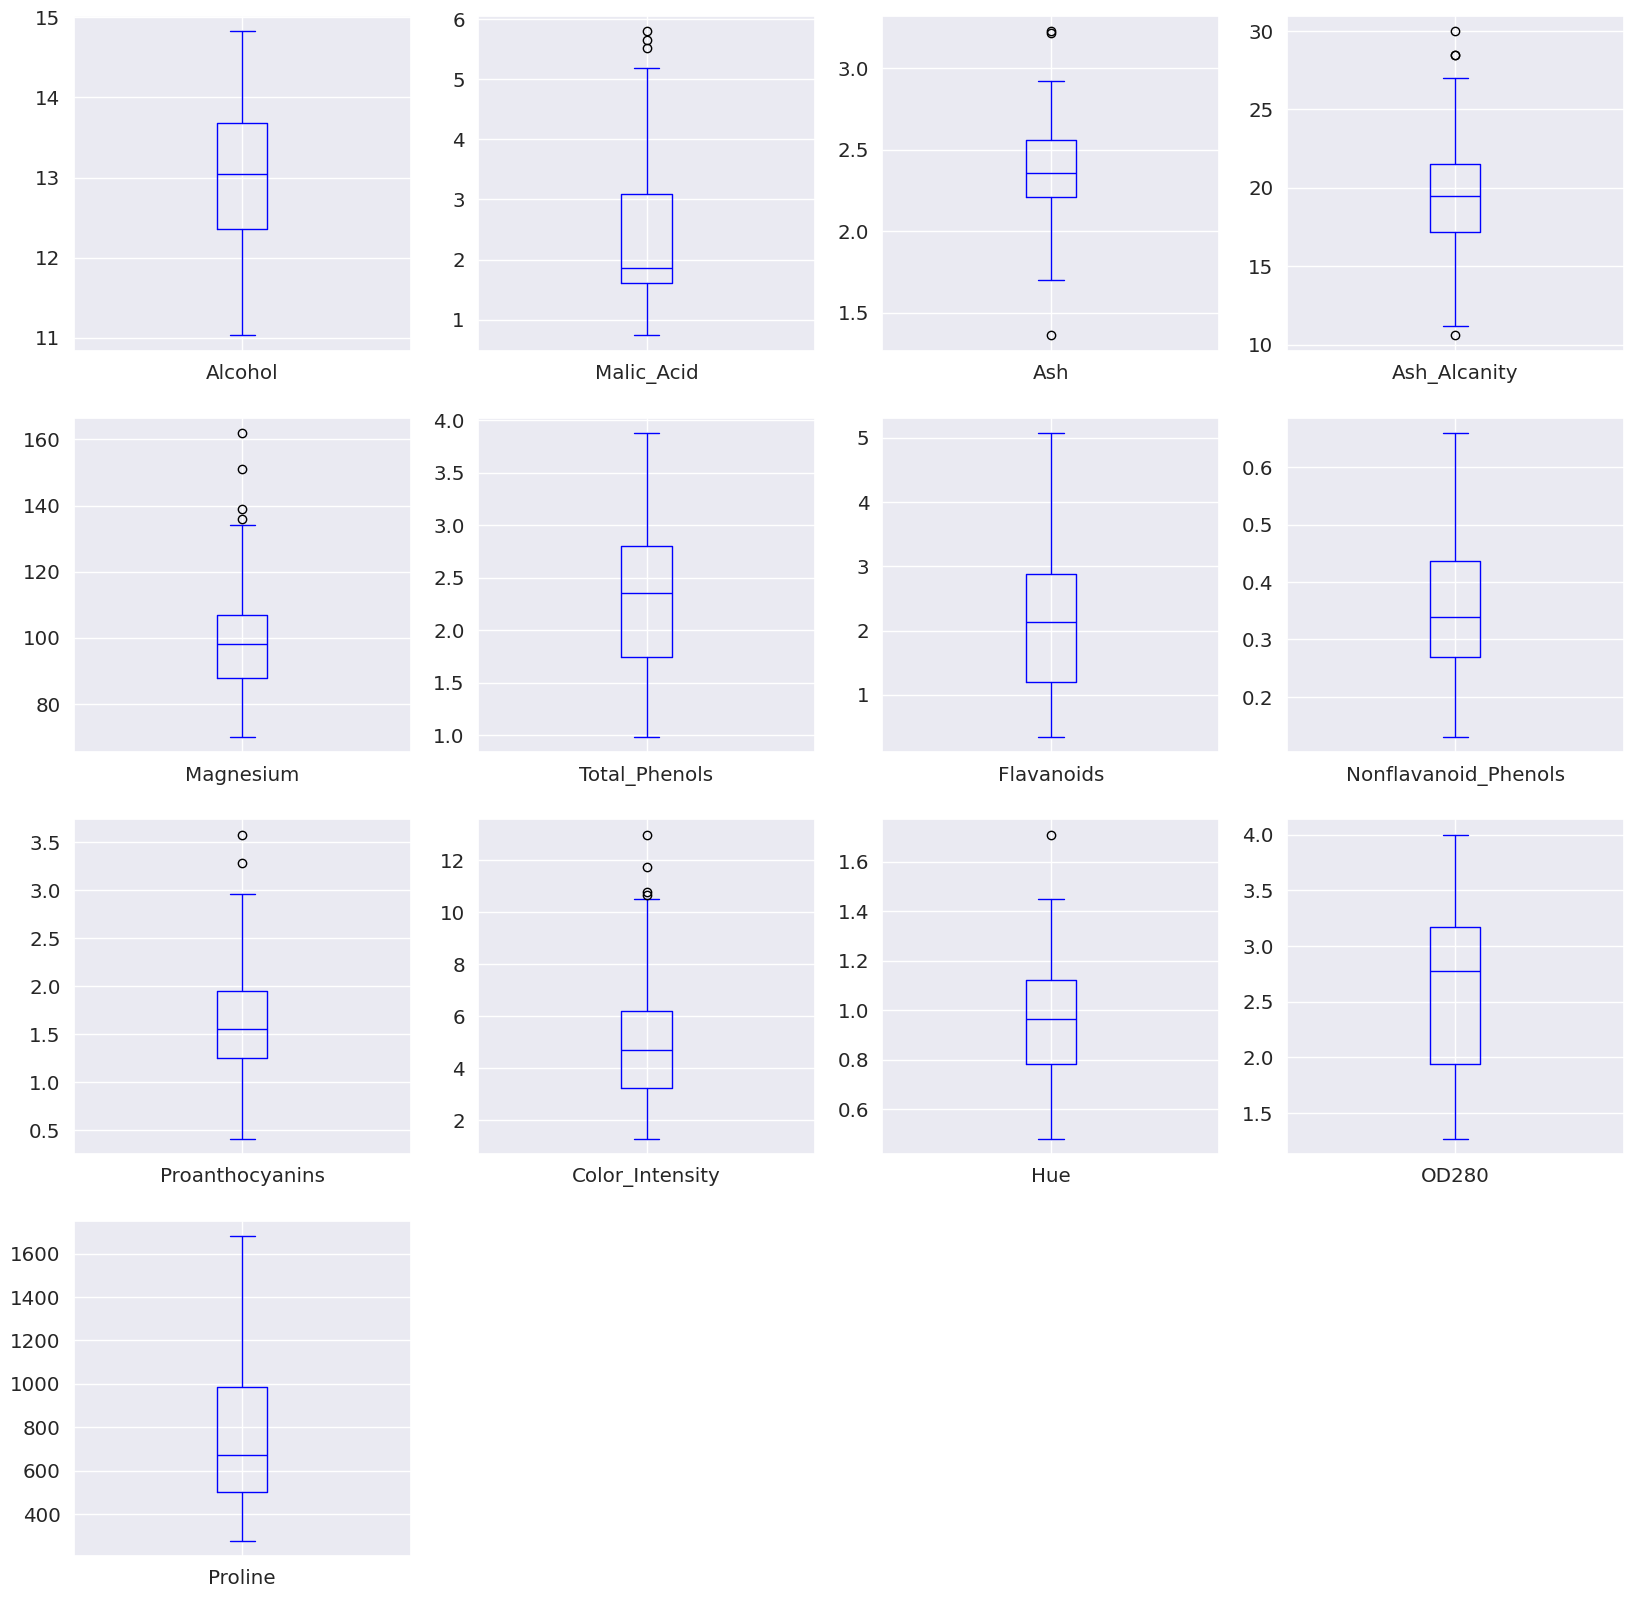

In [16]:
df.plot( kind = 'box', subplots = True, layout = (4,4), sharex = False, sharey = False, color = 'blue')
plt.title("Boxplots")
plt.show()

# Preprocessing

In [17]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(df), columns = df.columns)
#dfClust = pd.DataFrame(df)
#dfClust[dfClust.columns] = scaler.fit_transform(dfClust)

In [18]:
X.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-0.885468,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,0.095960,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,0.808997,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00


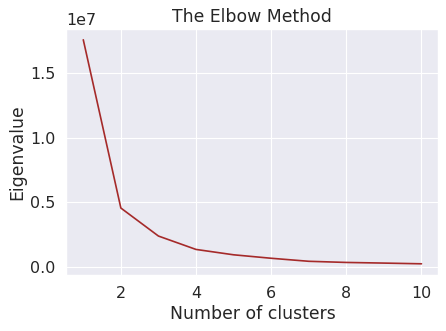

In [19]:
from sklearn.cluster import KMeans
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
    kmeans.fit(df)
    cs.append(kmeans.inertia_)

plt.figure(figsize=(6, 4), dpi=80)
plt.plot(range(1, 11), cs, color='brown')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Eigenvalue')
plt.show()

##### This elbow curve indicates 3 clusters would be a great choice.

# PCA

In [20]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)
dfPrin = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])

In [21]:
print(dfPrin.shape)
dfPrin.head()

(178, 2)


,PC1,PC2
0,3.316751,1.443463
1,2.209465,-0.333393
2,2.516740,1.031151
3,3.757066,2.756372
4,1.008908,0.869831


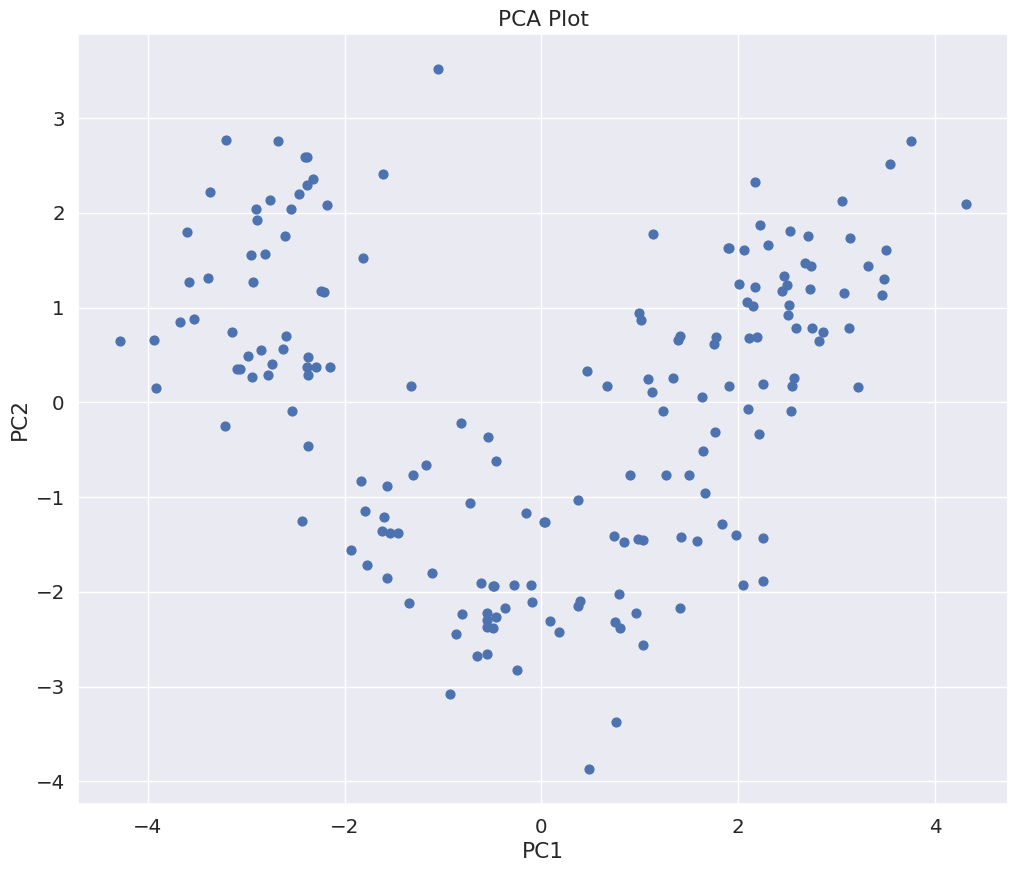

In [22]:
# Figure size
plt.figure(figsize=(12,10))
plt.scatter(dfPrin.iloc[:,0], dfPrin.iloc[:,1], s=40)
plt.title('PCA Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [23]:
# PCA
pca_var = PCA()
pca_var.fit(X)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


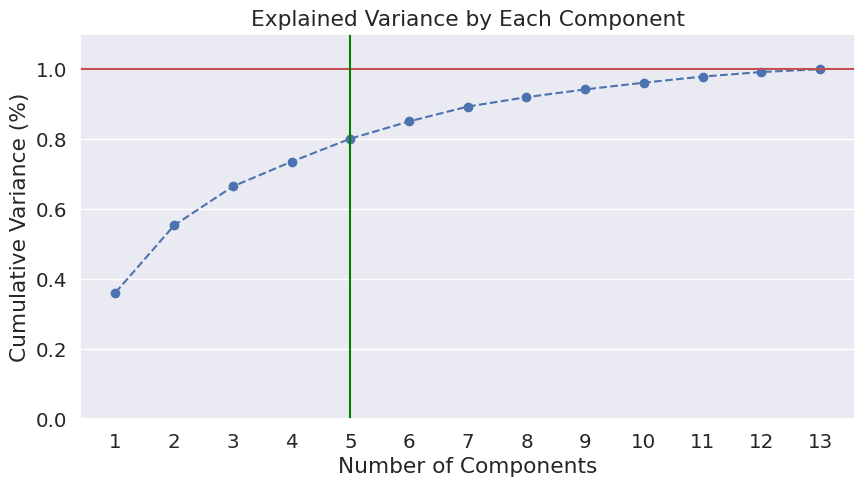

In [24]:
plt.figure(figsize=(10,5))
xi = np.arange(1, 1 + X.shape[1], step = 1)
yi = np.cumsum(pca_var.explained_variance_ratio_)
plt.plot(xi, yi, marker = 'o', linestyle = 'dashed', color = 'b')
plt.ylim(0.0,1.1)
plt.xlabel('Number of Components')
plt.xticks(np.arange(1, 1+X.shape[1], step=1))
plt.ylabel('Cumulative Variance (%)')
plt.title('Explained Variance by Each Component')
plt.axhline(y=1, color='r', linestyle='-')
plt.axvline(x = 5, color = 'green', linestyle = 'solid')
plt.gca().xaxis.grid(False)

##### Utilizing this plot, 5 components would explain ~ 80% of the variance.

# K-means clustering

#### Using 3 clusters

In [25]:
# KMeans, clusters = 3abs
kmeans = KMeans(n_clusters = 3, n_init = 15, max_iter = 500, random_state = 42)
clusters = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

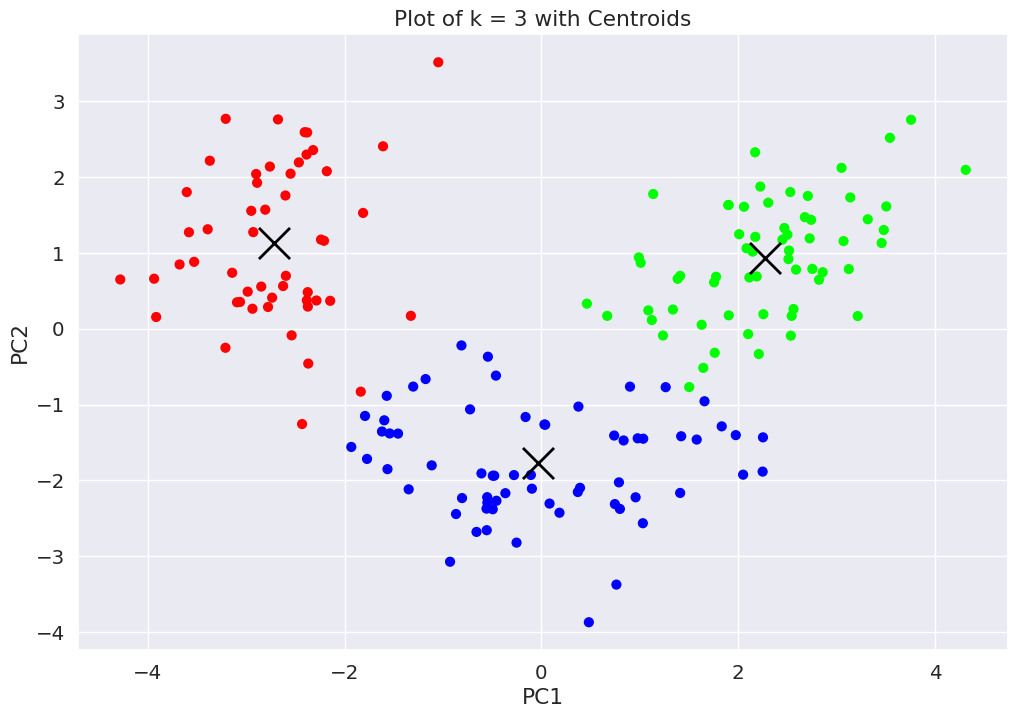

In [26]:
# Figure size
plt.figure(figsize=(12, 8))

# Scatterplot
plt.scatter(dfPrin.iloc[:,0], dfPrin.iloc[:,1], c = clusters, cmap = "brg", s = 40)
plt.scatter(x=centroids_pca[:,0], y=centroids_pca[:,1], marker = "x", s = 500, linewidths = 2, color = "black")
plt.title('Plot of k = 3 with Centroids')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

##### This plot shows good visual clustering with fairly well defined boundaries.

#### Using 4 clusters

In [27]:
# KMeans, clusters = 4
kmeans = KMeans(n_clusters = 4, n_init = 15, max_iter = 500, random_state = 42)
clusters = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

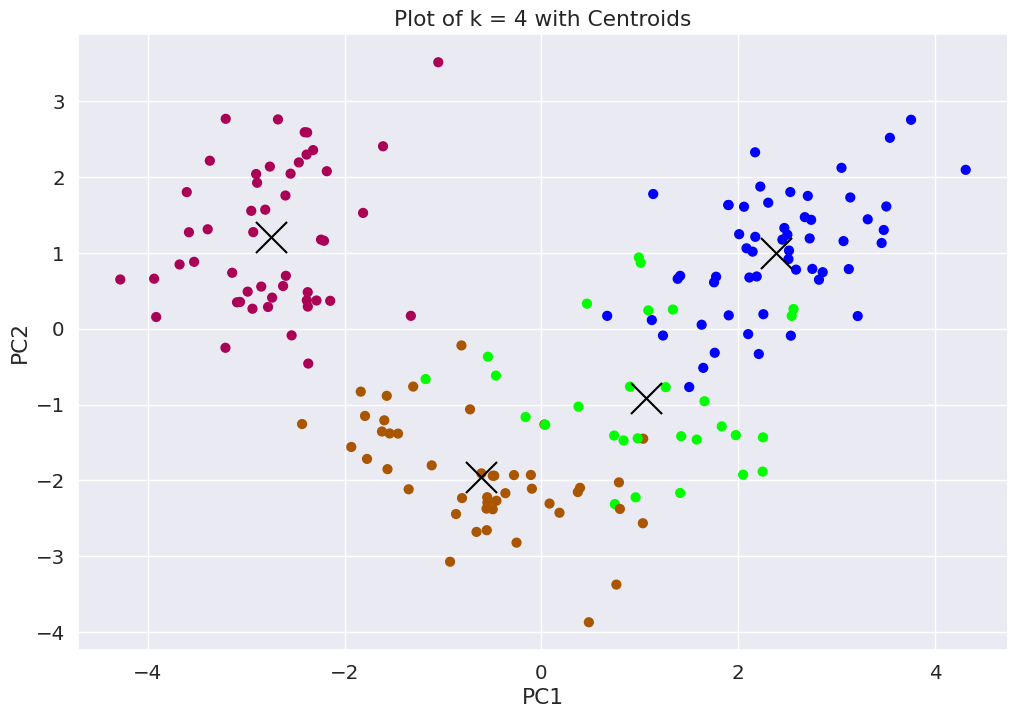

In [28]:
plt.figure(figsize=(12, 8))

# Scatterplot
plt.scatter(dfPrin.iloc[:,0], dfPrin.iloc[:,1], c = clusters, cmap = "brg", s = 40)
plt.scatter(x=centroids_pca[:,0], y=centroids_pca[:,1], marker = "x", s = 500, linewidths = 1.5, color = "black")
plt.title('Plot of k = 4 with Centroids')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

##### This plot shows that k = 4 is likely not the best choice (and we already know this from the Kaggle website) due to the fact that the boundaries are not as clearly defined as k = 3 clustering.  Many points are in each other's territories and cross boundaries.

# Hierarchical clustering

In [29]:
scaler = StandardScaler(with_std = True, with_mean = True)
dfScaled = scaler.fit_transform(X)
cluster = AgglomerativeClustering
dfClust = cluster(distance_threshold = 0, n_clusters = None, linkage='complete')
dfClust.fit(df)

,n_clusters,None
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,0
,compute_distances,False


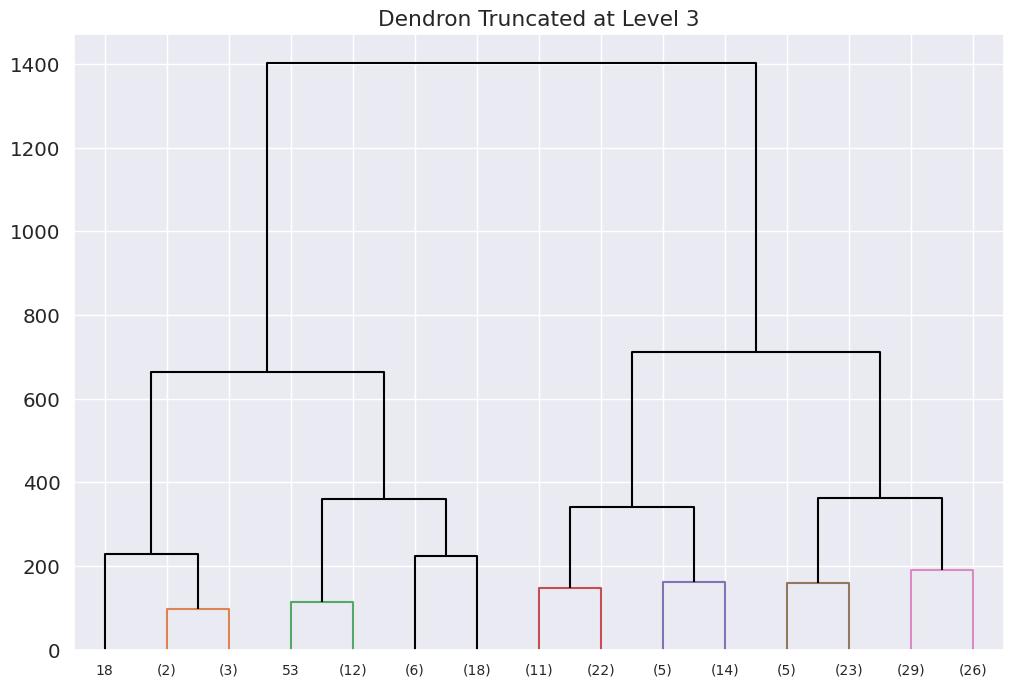

In [30]:
linkage = compute_linkage(dfClust)
fig, ax = plt.subplots(1, 1, figsize = (12, 8))
dendrogram(linkage, labels = df.index,
           ax = ax,
           color_threshold = 200, 
           truncate_mode = 'level',
           p = 3,
           above_threshold_color = 'black')
plt.xticks(fontsize = 10)
plt.title("Dendron Truncated at Level 3")
plt.show()